## 02_handcrafted_features

In [4]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\360Downloads\bioinformatics\Task\AIP


In [6]:
# 导入特征函数
from src.feature_handcrafted import extract_features

In [7]:
# 读取数据
train_path = PROJECT_ROOT / "data" / "processed" / "train.csv"
test_path = PROJECT_ROOT / "data" / "processed" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(3583, 2)
(897, 2)


,sequence,label
0,SLLLNGGCKVSNYDE,1
1,DAEFRHDSGYEVHHQ,1
2,GRTGRGKPGIYRFVAPGE,1
3,ASLKPEFVQIINAKN,1
4,KCEFQDAYVLLSEKK,1


In [8]:
# 检查标签分布
print("Train label counts:")
print(train_df["label"].value_counts())

print("\nTest label counts:")
print(test_df["label"].value_counts())

Train label counts:
label
0    2218
1    1365
Name: count, dtype: int64

Test label counts:
label
0    555
1    342
Name: count, dtype: int64


## 提取手工特征

In [9]:
X_train = []
for seq in tqdm(train_df["sequence"], desc="Extract train features"):
    X_train.append(extract_features(seq))

X_test = []
for seq in tqdm(test_df["sequence"], desc="Extract test features"):
    X_test.append(extract_features(seq))

X_train = np.array(X_train, dtype=float)
X_test = np.array(X_test, dtype=float)

y_train = train_df["label"].values
y_test = test_df["label"].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Extract train features:   0%|          | 0/3583 [00:00<?, ?it/s]

Extract test features: 100%|██████████| 897/897 [00:00<00:00, 5986.40it/s]

X_train shape: (3583, 441)
X_test shape: (897, 441)
y_train shape: (3583,)
y_test shape: (897,)


In [10]:
from src.feature_handcrafted import get_feature_names
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent

feature_names = get_feature_names()

print("特征数:", len(feature_names))
print("X_train列数:", X_train.shape[1])

assert len(feature_names) == X_train.shape[1], "特征名数量与特征维度不一致！"

save_dir = PROJECT_ROOT / "data" / "processed" / "handcrafted"
save_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"feature_name": feature_names}).to_csv(
    save_dir / "handcrafted_feature_names.csv",
    index=False
)

print("已保存:", save_dir / "handcrafted_feature_names.csv")

特征数: 441
X_train列数: 441
已保存: d:\360Downloads\bioinformatics\Task\AIP\data\processed\handcrafted\handcrafted_feature_names.csv


In [11]:
# 保存提取后的手工特征文件
feature_dir = PROJECT_ROOT / "data" / "processed" / "handcrafted"
os.makedirs(feature_dir, exist_ok=True)

np.save(feature_dir / "X_train_handcrafted.npy", X_train)
np.save(feature_dir / "X_test_handcrafted.npy", X_test)
np.save(feature_dir / "y_train.npy", y_train)
np.save(feature_dir / "y_test.npy", y_test)

print("Handcrafted features saved.")

Handcrafted features saved.


## 标准化

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(3583, 441) (897, 441)


## 定义评估函数

In [130]:
from sklearn.metrics import make_scorer, confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "specificity": make_scorer(specificity_score)
}

def evaluate_model(y_true, y_pred, y_prob):
    metrics = {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
          
    }
    return metrics


def print_metrics(metrics, title="Metrics"):
    print(f"===== {title} =====")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

## 训练过程

## （1）5-fold CV 跑 LightGBM

In [131]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgb_cv_results = cross_validate(
    lgb_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in lgb_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7382 ± 0.0088
test_precision: 0.6913 ± 0.0078
test_recall: 0.5648 ± 0.0291
test_f1: 0.6214 ± 0.0195
test_roc_auc: 0.7680 ± 0.0122
test_pr_auc: 0.6619 ± 0.0360
test_specificity: 0.8449 ± 0.0062


In [132]:
# 训练模型并且在独立测试集上评估

lgb_model.fit(X_train_scaled, y_train)

y_pred_lgb = lgb_model.predict(X_test_scaled)
y_prob_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

lgb_metrics = evaluate_model(y_test, y_pred_lgb, y_prob_lgb)
print_metrics(lgb_metrics, title="LightGBM Test")

[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7039
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 423
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380966 -> initscore=-0.485451
[LightGBM] [Info] Start training from score -0.485451
===== LightGBM Test =====
ACC: 0.7347
Precision: 0.6818
Recall: 0.5702
Specificity: 0.8360
F1: 0.6210
MCC: 0.4234
ROC_AUC: 0.7785
PR_AUC: 0.6821


c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\ysy_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## （2）5-fold CV 跑 SVM

In [133]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_cv_results = cross_validate(
    svm_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in svm_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.6846 ± 0.0128
test_precision: 0.6606 ± 0.0304
test_recall: 0.3538 ± 0.0203
test_f1: 0.4608 ± 0.0240
test_roc_auc: 0.7143 ± 0.0130
test_pr_auc: 0.6005 ± 0.0180
test_specificity: 0.8882 ± 0.0097


In [134]:
# 训练SVM并在独立测试集上评估
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_metrics = evaluate_model(y_test, y_pred_svm, y_prob_svm)
print_metrics(svm_metrics, title="SVM Test")

===== SVM Test =====
ACC: 0.6756
Precision: 0.6281
Recall: 0.3655
Specificity: 0.8667
F1: 0.4621
MCC: 0.2714
ROC_AUC: 0.7286
PR_AUC: 0.5883


## （3）5-fold CV 跑 MLP

In [135]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_cv_results = cross_validate(
    mlp_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in mlp_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.6523 ± 0.0149
test_precision: 0.5638 ± 0.0327
test_recall: 0.4095 ± 0.0656
test_f1: 0.4701 ± 0.0414
test_roc_auc: 0.6641 ± 0.0134
test_pr_auc: 0.5408 ± 0.0188
test_specificity: 0.8017 ± 0.0473


In [136]:
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

mlp_metrics = evaluate_model(y_test, y_pred_mlp, y_prob_mlp)
print_metrics(mlp_metrics, title="MLP Test")

===== MLP Test =====
ACC: 0.6745
Precision: 0.5874
Recall: 0.4912
Specificity: 0.7874
F1: 0.5350
MCC: 0.2904
ROC_AUC: 0.7004
PR_AUC: 0.5653


## （4）5-fold CV跑XGBoost

In [137]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

xgb_cv_results = cross_validate(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in xgb_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.7365 ± 0.0039
test_precision: 0.6880 ± 0.0134
test_recall: 0.5656 ± 0.0186
test_f1: 0.6204 ± 0.0078
test_roc_auc: 0.7729 ± 0.0088
test_pr_auc: 0.6707 ± 0.0369
test_specificity: 0.8418 ± 0.0139


In [138]:
# 独立测试集评估性能
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_metrics = evaluate_model(y_test, y_pred_xgb, y_prob_xgb)
print_metrics(xgb_metrics, title="XGBoost Test")

c:\Users\User\.conda\envs\ysy_env\lib\site-packages\xgboost\training.py:200: UserWarning: [17:43:18] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBoost Test =====
ACC: 0.7269
Precision: 0.6702
Recall: 0.5585
Specificity: 0.8306
F1: 0.6093
MCC: 0.4059
ROC_AUC: 0.7855
PR_AUC: 0.6845


# （5）5-fold CV跑 LR

In [139]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_cv_results = cross_validate(
    lr_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in lr_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")

test_accuracy: 0.6109 ± 0.0106
test_precision: 0.4912 ± 0.0114
test_recall: 0.5788 ± 0.0148
test_f1: 0.5313 ± 0.0104
test_roc_auc: 0.6324 ± 0.0063
test_pr_auc: 0.5083 ± 0.0170
test_specificity: 0.6307 ± 0.0172


In [140]:
# 独立测试集评估性能
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics = evaluate_model(y_test, y_pred_lr, y_prob_lr)
print_metrics(lr_metrics, title="Logistic Regression Test")

===== Logistic Regression Test =====
ACC: 0.6154
Precision: 0.4964
Recall: 0.6023
Specificity: 0.6234
F1: 0.5443
MCC: 0.2199
ROC_AUC: 0.6596
PR_AUC: 0.5291


#  (6) 5-fold CV跑RF

In [119]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_cv_results = cross_validate(
    rf_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in rf_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")


test_accuracy: 0.7346 ± 0.0072
test_precision: 0.7014 ± 0.0210
test_recall: 0.5297 ± 0.0130
test_f1: 0.6032 ± 0.0083
test_roc_auc: 0.7877 ± 0.0107
test_pr_auc: 0.6739 ± 0.0265
test_specificity: 0.8607 ± 0.0149


In [120]:
# 独立测试集评估性能
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_metrics = evaluate_model(y_test, y_pred_rf, y_prob_rf)
print_metrics(rf_metrics, title="Random Forest Test")

===== Random Forest Test =====
ACC: 0.7280
Precision: 0.6801
Recall: 0.5409
F1: 0.6026
MCC: 0.4059
ROC_AUC: 0.7980
PR_AUC: 0.6783
Specificity: 0.8432


# (7) 5-fold CV跑ET

In [121]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

et_cv_results = cross_validate(
    et_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

for metric_name, values in et_cv_results.items():
    if metric_name.startswith("test_"):
        print(f"{metric_name}: {values.mean():.4f} ± {values.std():.4f}")


test_accuracy: 0.7254 ± 0.0029
test_precision: 0.7045 ± 0.0094
test_recall: 0.4813 ± 0.0151
test_f1: 0.5717 ± 0.0089
test_roc_auc: 0.7986 ± 0.0041
test_pr_auc: 0.6776 ± 0.0173
test_specificity: 0.8756 ± 0.0087


In [122]:
# 独立测试集评估性能
et_model.fit(X_train_scaled, y_train)

y_pred_et = et_model.predict(X_test_scaled)
y_prob_et = et_model.predict_proba(X_test_scaled)[:, 1]

et_metrics = evaluate_model(y_test, y_pred_et, y_prob_et)
print_metrics(et_metrics, title="Extra Trees Test")

===== Extra Trees Test =====
ACC: 0.7302
Precision: 0.7066
Recall: 0.5000
F1: 0.5856
MCC: 0.4072
ROC_AUC: 0.8141
PR_AUC: 0.6814
Specificity: 0.8721


## 汇总结果表

## （1）table

In [123]:
results_df = pd.DataFrame([
    {"Model": "LightGBM", **lgb_metrics},
    {"Model": "SVM", **svm_metrics},
    {"Model": "MLP", **mlp_metrics},
    {"Model": "XGBoost", **xgb_metrics},
    {"Model": "Logistic Regression", **lr_metrics},
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "Extra Trees", **et_metrics},
])

results_df

,Model,ACC,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,Specificity
0,LightGBM,0.734671,0.681818,0.570175,0.621019,0.423358,0.778542,0.682134,0.836036
1,SVM,0.675585,0.628141,0.365497,0.462107,0.271394,0.728623,0.588322,0.866667
2,MLP,0.674470,0.587413,0.491228,0.535032,0.290376,0.700369,0.565310,0.787387
3,XGBoost,0.726867,0.670175,0.558480,0.609250,0.405914,0.785522,0.684528,0.830631
4,Logistic Regression,0.615385,0.496386,0.602339,0.544254,0.219920,0.659575,0.529102,0.623423
5,Random Forest,0.727982,0.680147,0.540936,0.602606,0.405946,0.798048,0.678345,0.843243
6,Extra Trees,0.730212,0.706612,0.500000,0.585616,0.407154,0.814101,0.681402,0.872072


In [124]:
result_dir = PROJECT_ROOT / "results" / "tables"
os.makedirs(result_dir, exist_ok=True)

results_df.to_csv(result_dir / "handcrafted_model_results.csv", index=False)
print("Results saved.")

Results saved.


## （2）画 ROC 曲线

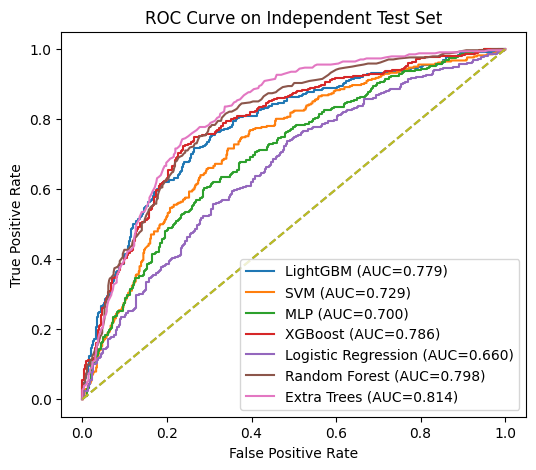

In [125]:
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_et, tpr_et, _ = roc_curve(y_test, y_prob_et)


plt.figure(figsize=(6, 5))
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={lgb_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={svm_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC={mlp_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_metrics['ROC_AUC']:.3f})")
plt.plot(fpr_et, tpr_et, label=f"Extra Trees (AUC={et_metrics['ROC_AUC']:.3f})")


plt.plot([0, 1], [0, 1], [0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Independent Test Set")
plt.legend()
plt.show()

## （2）画PR曲线

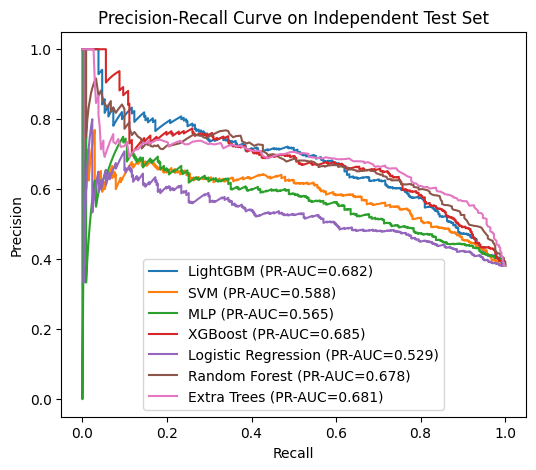

In [126]:
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_prob_lgb)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_et, recall_et, _ = precision_recall_curve(y_test, y_prob_et)

plt.figure(figsize=(6, 5))
plt.plot(recall_lgb, precision_lgb, label=f"LightGBM (PR-AUC={lgb_metrics['PR_AUC']:.3f})")
plt.plot(recall_svm, precision_svm, label=f"SVM (PR-AUC={svm_metrics['PR_AUC']:.3f})")
plt.plot(recall_mlp, precision_mlp, label=f"MLP (PR-AUC={mlp_metrics['PR_AUC']:.3f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (PR-AUC={xgb_metrics['PR_AUC']:.3f})")
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (PR-AUC={lr_metrics['PR_AUC']:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (PR-AUC={rf_metrics['PR_AUC']:.3f})")
plt.plot(recall_et, precision_et, label=f"Extra Trees (PR-AUC={et_metrics['PR_AUC']:.3f})")



plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve on Independent Test Set")
plt.legend()
plt.show()

# （3）柱状图

In [141]:
def summarize_cv_results(cv_results, model_name):
    summary = {
        "Model": model_name,
        "ACC": np.mean(cv_results["test_accuracy"]),
        "Precision": np.mean(cv_results["test_precision"]),
        "Recall": np.mean(cv_results["test_recall"]),
        "Specificity":np.mean(cv_results["test_specificity"]),
        "F1": np.mean(cv_results["test_f1"]),
        "ROC_AUC": np.mean(cv_results["test_roc_auc"]),
        "PR_AUC": np.mean(cv_results["test_pr_auc"])
    }
    return summary

In [142]:
cv_summary_list = []

cv_summary_list.append(summarize_cv_results(lgb_cv_results, "LightGBM"))
cv_summary_list.append(summarize_cv_results(svm_cv_results, "SVM"))
cv_summary_list.append(summarize_cv_results(xgb_cv_results, "XGBoost"))
cv_summary_list.append(summarize_cv_results(mlp_cv_results, "MLP"))
cv_summary_list.append(summarize_cv_results(lr_cv_results, "LogReg"))
cv_summary_list.append(summarize_cv_results(rf_cv_results, "RandomForest"))
cv_summary_list.append(summarize_cv_results(et_cv_results, "ExtraTrees"))

cv_df = pd.DataFrame(cv_summary_list)
cv_df

,Model,ACC,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,LightGBM,0.738205,0.691323,0.564835,0.844908,0.621396,0.767998,0.661881
1,SVM,0.684618,0.660577,0.353846,0.888188,0.460761,0.714274,0.600498
2,XGBoost,0.736533,0.688045,0.565568,0.841756,0.620442,0.772930,0.670677
3,MLP,0.652251,0.563828,0.409524,0.801675,0.470052,0.664121,0.540830
4,LogReg,0.610939,0.491178,0.578755,0.630740,0.531265,0.632409,0.508310
5,RandomForest,0.734584,0.701422,0.529670,0.860698,0.603243,0.787733,0.673943
6,ExtraTrees,0.725370,0.704499,0.481319,0.875563,0.571671,0.798604,0.677620


In [143]:
test_df = pd.DataFrame([
    {"Model": "LightGBM", **lgb_metrics},
    {"Model": "SVM", **svm_metrics},
    {"Model": "MLP", **mlp_metrics},
    {"Model": "XGBoost", **xgb_metrics}, 
    {"Model": "LogReg", **lr_metrics},
    {"Model": "RandomForest", **rf_metrics},
    {"Model": "ExtraTrees", **et_metrics},
])

test_df

,Model,ACC,Precision,Recall,Specificity,F1,MCC,ROC_AUC,PR_AUC
0,LightGBM,0.734671,0.681818,0.570175,0.836036,0.621019,0.423358,0.778542,0.682134
1,SVM,0.675585,0.628141,0.365497,0.866667,0.462107,0.271394,0.728623,0.588322
2,MLP,0.674470,0.587413,0.491228,0.787387,0.535032,0.290376,0.700369,0.565310
3,XGBoost,0.726867,0.670175,0.558480,0.830631,0.609250,0.405914,0.785522,0.684528
4,LogReg,0.615385,0.496386,0.602339,0.623423,0.544254,0.219920,0.659575,0.529102
5,RandomForest,0.727982,0.680147,0.540936,0.843243,0.602606,0.405946,0.798048,0.678345
6,ExtraTrees,0.730212,0.706612,0.500000,0.872072,0.585616,0.407154,0.814101,0.681402


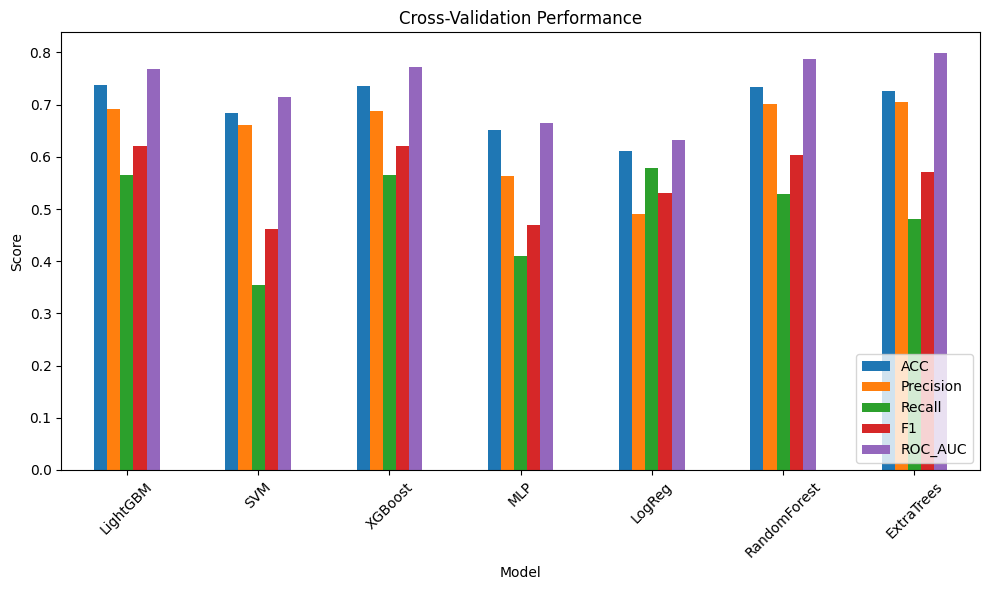

In [100]:
metrics_to_plot = ["ACC", "Precision", "Recall", "F1", "ROC_AUC"]

cv_df_plot = cv_df.set_index("Model")[metrics_to_plot]

cv_df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Cross-Validation Performance")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

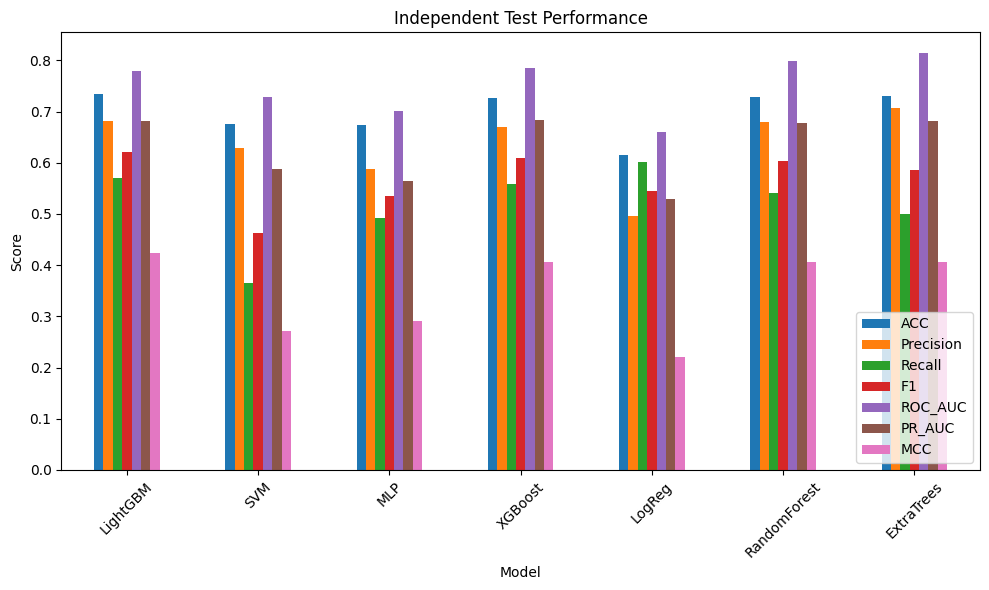

In [101]:
metrics_to_plot = ["ACC", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "MCC"]

test_df_plot = test_df.set_index("Model")[metrics_to_plot]

test_df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Independent Test Performance")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

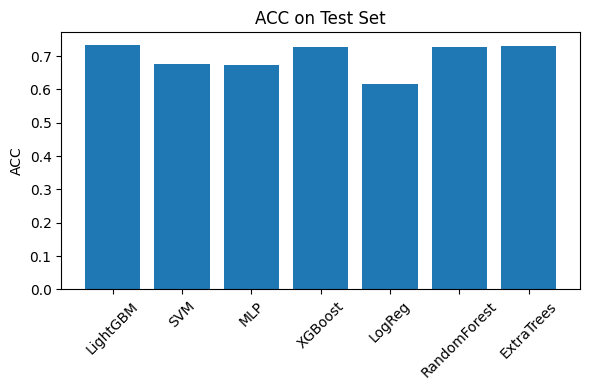

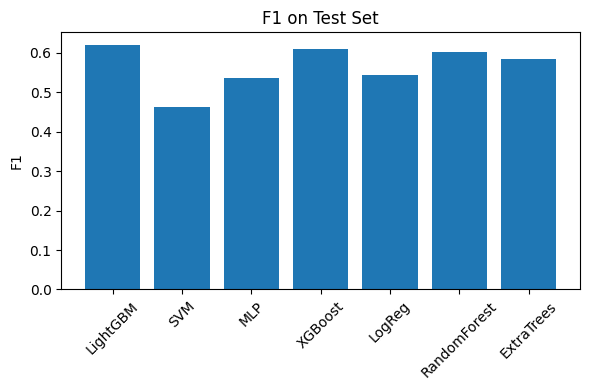

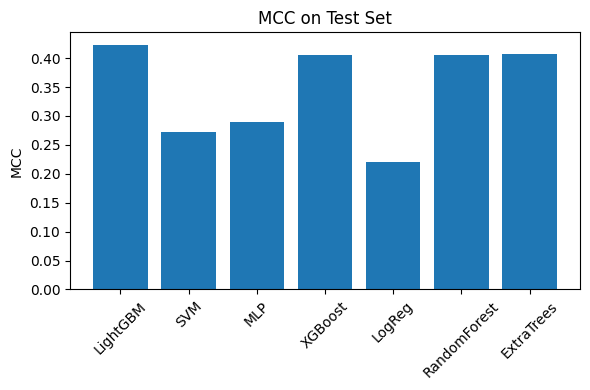

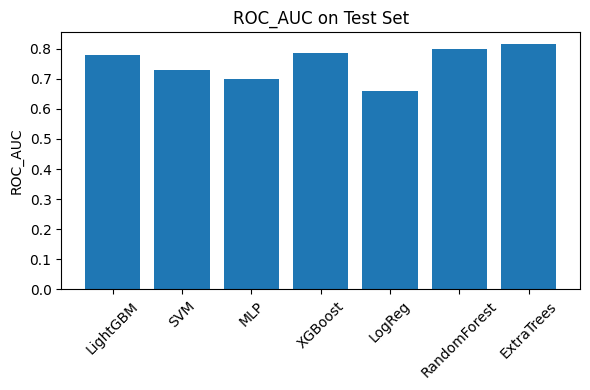

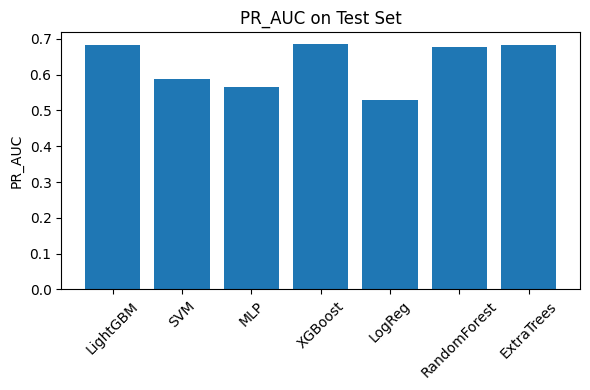

In [102]:
for metric in ["ACC", "F1", "MCC", "ROC_AUC", "PR_AUC"]:
    plt.figure(figsize=(6, 4))
    plt.bar(test_df["Model"], test_df[metric])
    plt.title(f"{metric} on Test Set")
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()